In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import AFT_tools as AFT

path = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260107/MTs.zarr'

path2='/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr/MTs.zarr'

za = zarr.open_array(path, read_only=True)
#MTs = za[:]

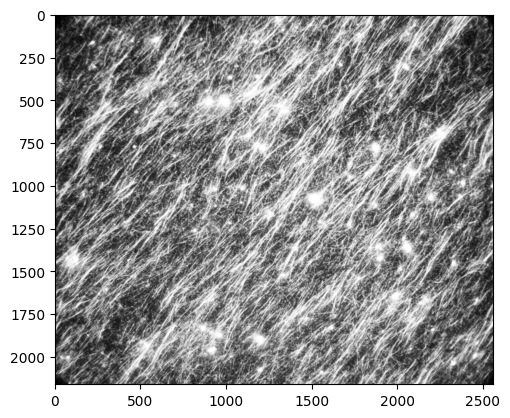

In [3]:
plt.imshow(za[0, :, :], cmap='gray')

In [10]:
# AFT parameters
window_size_um = 10 # MTs length = 10um
frame = 100

scale = 0.11  # um/pixel

#### required parameters ####
window_size = int(window_size_um/scale)
overlap = 0.8
neighborhood_radius = 1

d = 30

#crop, mask = crop_around_trajectory(traj_solo, MTs_smoothed, d, scale)

In [ ]:
AFT.image_local_order(za[200,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=True, plot_angles=True, plot_eccentricity=True,
                                                             save_figures=False)

In [23]:
x, y, u, v, im_theta, im_eccentricity = AFT.image_local_order(za[0:550:10,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

[Text(0.5, 0, 't[s]'), Text(0, 0.5, 'Order parameter'), (0.0, 1.0)]

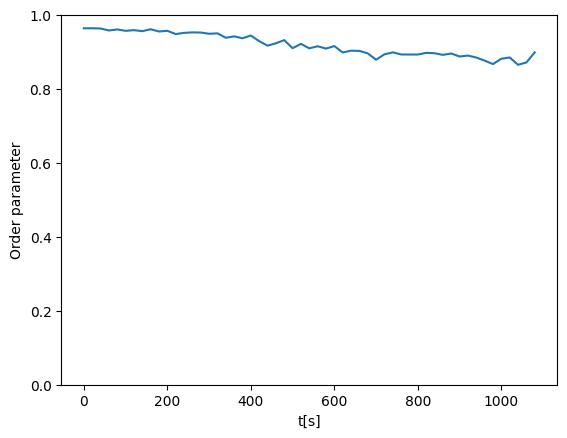

In [26]:
im_order_parameter = AFT.calculate_order_parameter(im_theta, neighborhood_radius)

fig, ax = plt.subplots()
ax.plot(np.arange(0, 550*2, 2*10), im_order_parameter)

ax.set(xlabel='t[s]',
       ylabel='Order parameter',
       ylim=(0, 1))

#print('The order parameter is {0}'.format(im_order_parameter))

[Text(0.5, 0, 't[s]'),
 Text(0, 0.5, 'Mean angle [rad]'),
 (-1.5707963267948966, 1.5707963267948966)]

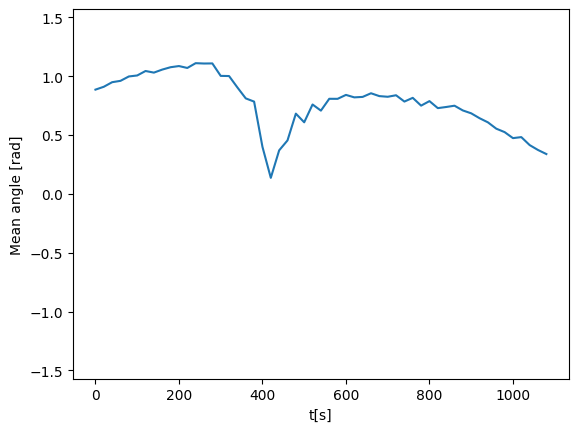

In [52]:
means = []
for theta in im_theta:
    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))
    means.append(mean)
    
fig, ax = plt.subplots()
ax.plot(np.arange(0, 550*2, 2*10), np.abs(means))
ax.set(xlabel='t[s]',
       ylabel='Mean angle [rad]',
       ylim=(-np.pi/2, np.pi/2))

In [44]:
za2 = zarr.open_array(path2, read_only=True)
x2, y2, u2, v2, im_theta2, im_eccentricity2 = AFT.image_local_order(za2[:,:,:], window_size, overlap, save_path='', eccentricity_thresh = 0.2,
                                                             plot_overlay=False, plot_angles=False, plot_eccentricity=False,
                                                             save_figures=False)

[Text(0.5, 0, 't[s]'),
 Text(0, 0.5, 'Mean angle [rad]'),
 (-1.5707963267948966, 1.5707963267948966)]

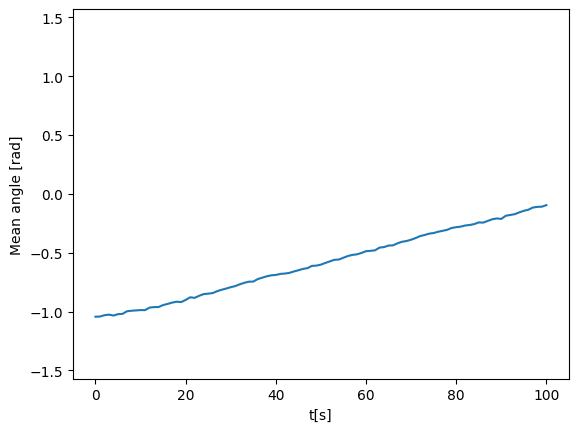

In [46]:
means2 = []
for theta in im_theta2:
    mean = np.arctan2(np.nansum(np.sin(theta)), np.nansum(np.cos(theta)))
    means2.append(mean)


fig, ax = plt.subplots()
ax.plot(means2)
ax.set(xlabel='t[s]',
       ylabel='Mean angle [rad]',
       ylim=(-np.pi/2, np.pi/2))

[Text(0.5, 0, 't[s]'), Text(0, 0.5, 'Order parameter'), (0.0, 1.0)]

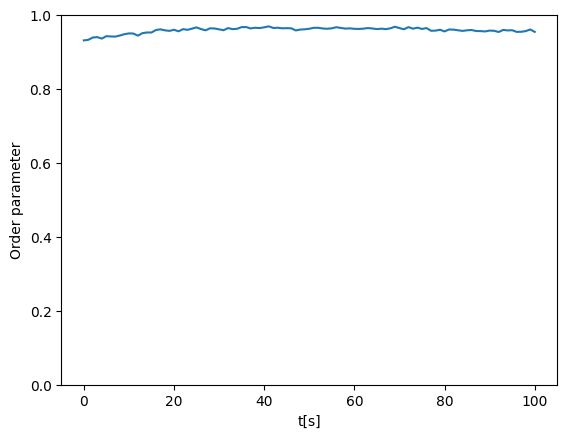

In [47]:
im_order_parameter2 = AFT.calculate_order_parameter(im_theta2, neighborhood_radius)

fig, ax = plt.subplots()
ax.plot(im_order_parameter2)

ax.set(xlabel='t[s]',
       ylabel='Order parameter',
       ylim=(0, 1))